In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## load the data

In [2]:
import glob

files = glob.glob("chicago_crime_*.csv")
print(files)

['chicago_crime_2018.csv', 'chicago_crime_2019.csv', 'chicago_crime_2020.csv', 'chicago_crime_2021.csv', 'chicago_crime_2022.csv', 'chicago_crime_2023.csv']


In [3]:
import pandas as pd
import glob

files = glob.glob("chicago_crime_*.csv")

crime = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index=True
)

weather = pd.read_csv("chicago_temps_18-23_clean.csv")
community = pd.read_csv("chicago_areas.csv")

## inspection of data

In [4]:
print(crime.shape)
print(weather.shape)
print(community.shape)

(1450979, 13)
(2191, 5)
(77, 5)


In [5]:
crime.head()

,date_reported,city_block,primary_type,primary_description,location_description,arrest,domestic,community_area,year,latitude,longitude,location,primery_description
0,8/15/2018 12:35,102XX W ZEMKE RD,DECEPTIVE PRACTICE,"THEFT BY LESSEE,MOTOR VEH",OTHER,False,False,76,2018,NaN,NaN,NaN,NaN
1,8/12/2018 8:09,051XX W CHICAGO AVE,NARCOTICS,MANU/DELIVER: HEROIN (WHITE),VEHICLE NON-COMMERCIAL,True,False,25,2018,NaN,NaN,NaN,NaN
2,4/14/2018 18:00,056XX W DIVERSEY AVE,DECEPTIVE PRACTICE,FRAUD OR CONFIDENCE GAME,OTHER,False,False,19,2018,NaN,NaN,NaN,NaN
3,12/22/2018 11:35,014XX E 53RD ST,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,NaN,False,False,41,2018,NaN,NaN,NaN,NaN
4,10/5/2018 17:15,102XX W ZEMKE RD,DECEPTIVE PRACTICE,"THEFT BY LESSEE,MOTOR VEH",OTHER,False,False,76,2018,NaN,NaN,NaN,NaN


In [7]:
weather.head()

,weather_date,temp_high,temp_low,average,precipitation
0,2018-01-01,1,-9,-4.0,0.0
1,2018-01-02,8,-9,-0.5,0.0
2,2018-01-03,17,6,11.5,0.0
3,2018-01-04,12,0,6.0,0.0
4,2018-01-05,11,-1,5.0,0.0


In [6]:
community.head()

,community_id,name,population,area_sq_mi,density
0,1,rogers park,55628,1.84,30232.61
1,2,west ridge,77122,3.53,21847.59
2,3,uptown,57182,2.32,24647.41
3,4,lincoln square,40494,2.56,15817.97
4,5,north center,35114,2.05,17128.78


In [7]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450979 entries, 0 to 1450978
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   date_reported         1450979 non-null  object 
 1   city_block            1450979 non-null  object 
 2   primary_type          1450979 non-null  object 
 3   primary_description   1189780 non-null  object 
 4   location_description  1444263 non-null  object 
 5   arrest                1450979 non-null  bool   
 6   domestic              1450979 non-null  bool   
 7   community_area        1450979 non-null  int64  
 8   year                  1450979 non-null  int64  
 9   latitude              1428145 non-null  float64
 10  longitude             1428145 non-null  float64
 11  location              1428145 non-null  object 
 12  primery_description   261199 non-null   object 
dtypes: bool(2), float64(2), int64(2), object(7)
memory usage: 124.5+ MB


In [8]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   weather_date   2191 non-null   object 
 1   temp_high      2191 non-null   int64  
 2   temp_low       2191 non-null   int64  
 3   average        2191 non-null   float64
 4   precipitation  2191 non-null   float64
dtypes: float64(2), int64(2), object(1)
memory usage: 85.7+ KB


In [9]:
community.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   community_id  77 non-null     int64  
 1   name          77 non-null     object 
 2   population    77 non-null     int64  
 3   area_sq_mi    77 non-null     float64
 4   density       77 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 3.1+ KB


## clean data

In [10]:
crime.isnull().sum()

date_reported                 0
city_block                    0
primary_type                  0
primary_description      261199
location_description       6716
arrest                        0
domestic                      0
community_area                0
year                          0
latitude                  22834
longitude                 22834
location                  22834
primery_description     1189780
dtype: int64

In [11]:
weather.isnull().sum()

weather_date     0
temp_high        0
temp_low         0
average          0
precipitation    0
dtype: int64

In [12]:
community.isnull().sum()

community_id    0
name            0
population      0
area_sq_mi      0
density         0
dtype: int64

In [13]:
crime.duplicated().sum()


np.int64(2223)

In [14]:
crime.describe(include="all")

,date_reported,city_block,primary_type,primary_description,location_description,arrest,domestic,community_area,year,latitude,longitude,location,primery_description
count,1450979,1450979,1450979,1189780,1444263,1450979,1450979,1.450979e+06,1.450979e+06,1.428145e+06,1.428145e+06,1428145,261199
unique,701748,36592,34,485,191,2,2,NaN,NaN,NaN,NaN,355451,293
top,1/1/2018 0:00,001XX N STATE ST,THEFT,SIMPLE,STREET,False,False,NaN,NaN,NaN,NaN,"(41.883500187, -87.627876698)",SIMPLE
freq,139,4359,321957,135055,363349,1221786,1189171,NaN,NaN,NaN,NaN,2123,29880
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.666512e+01,2.020462e+03,4.184395e+01,-8.766953e+01,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.152768e+01,1.769040e+00,8.734770e-02,5.966784e-02,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,2.018000e+03,3.661945e+01,-9.168657e+01,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.300000e+01,2.019000e+03,4.176821e+01,-8.771178e+01,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.200000e+01,2.020000e+03,4.186193e+01,-8.766295e+01,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300000e+01,2.022000e+03,4.190673e+01,-8.762727e+01,NaN,NaN


In [15]:
community.duplicated().sum()

np.int64(0)

In [26]:
community.describe()

,community_id,population,area_sq_mi,density
count,77.000000,77.000000,77.000000,77.000000
mean,39.000000,35667.376623,2.997662,13246.017532
std,22.371857,23675.473010,1.972510,7429.659729
min,1.000000,2527.000000,0.580000,1005.850000
25%,20.000000,18628.000000,1.780000,8173.650000
50%,39.000000,29647.000000,2.860000,11722.410000
75%,58.000000,45053.000000,3.550000,16563.600000
max,77.000000,105481.000000,13.340000,38496.720000


In [23]:
weather.duplicated().sum()


np.int64(0)

In [16]:
weather.describe()

,temp_high,temp_low,average,precipitation
count,2191.000000,2191.000000,2191.000000,2191.000000
mean,60.503880,43.912369,52.208124,0.106737
std,21.092985,18.983857,19.787225,0.295985
min,-10.000000,-23.000000,-16.500000,0.000000
25%,43.000000,30.000000,36.500000,0.000000
50%,61.000000,43.000000,51.500000,0.000000
75%,80.000000,62.000000,70.500000,0.050000
max,100.000000,81.000000,87.500000,3.530000


In [28]:
crime.columns

Index(['date_reported', 'city_block', 'primary_type', 'primary_description',
       'location_description', 'arrest', 'domestic', 'community_area', 'year',
       'latitude', 'longitude', 'location', 'primery_description'],
      dtype='object')

In [29]:
print(crime.columns.tolist())

['date_reported', 'city_block', 'primary_type', 'primary_description', 'location_description', 'arrest', 'domestic', 'community_area', 'year', 'latitude', 'longitude', 'location', 'primery_description']


In [30]:
crime.iloc[:, [3, 12]].head(10)

,primary_description,primery_description
0,"THEFT BY LESSEE,MOTOR VEH",NaN
1,MANU/DELIVER: HEROIN (WHITE),NaN
2,FRAUD OR CONFIDENCE GAME,NaN
3,FINANCIAL IDENTITY THEFT OVER $ 300,NaN
4,"THEFT BY LESSEE,MOTOR VEH",NaN
5,AUTOMOBILE,NaN
6,EMBEZZLEMENT,NaN
7,OTHER VEHICLE OFFENSE,NaN
8,POSS: HEROIN(WHITE),NaN
9,"THEFT BY LESSEE,MOTOR VEH",NaN


In [31]:
(crime.iloc[:, 3] == crime.iloc[:, 12]).all()

np.False_

In [32]:
crime.duplicated().sum()

np.int64(2223)

In [33]:
crime = crime.iloc[:, :-1]

In [34]:
crime.drop_duplicates(inplace=True)

In [35]:
crime.duplicated().sum()

np.int64(0)

In [36]:
crime.isnull().sum()

date_reported                0
city_block                   0
primary_type                 0
primary_description     260649
location_description      6706
arrest                       0
domestic                     0
community_area               0
year                         0
latitude                 22770
longitude                22770
location                 22770
dtype: int64

## feature engineering

In [17]:
crime["date_reported"] = pd.to_datetime(crime["date_reported"])

In [18]:
crime.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1450979 entries, 0 to 1450978
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   date_reported         1450979 non-null  datetime64[ns]
 1   city_block            1450979 non-null  object        
 2   primary_type          1450979 non-null  object        
 3   primary_description   1189780 non-null  object        
 4   location_description  1444263 non-null  object        
 5   arrest                1450979 non-null  bool          
 6   domestic              1450979 non-null  bool          
 7   community_area        1450979 non-null  int64         
 8   year                  1450979 non-null  int64         
 9   latitude              1428145 non-null  float64       
 10  longitude             1428145 non-null  float64       
 11  location              1428145 non-null  object        
 12  primery_description   261199 non-null   ob

In [19]:
crime["Month"] = crime["date_reported"].dt.month
crime["Month_Name"] = crime["date_reported"].dt.month_name()

crime["Day"] = crime["date_reported"].dt.day
crime["Day_Name"] = crime["date_reported"].dt.day_name()

crime["Hour"] = crime["date_reported"].dt.hour

# top 10 crime types(UNIVARIATE)

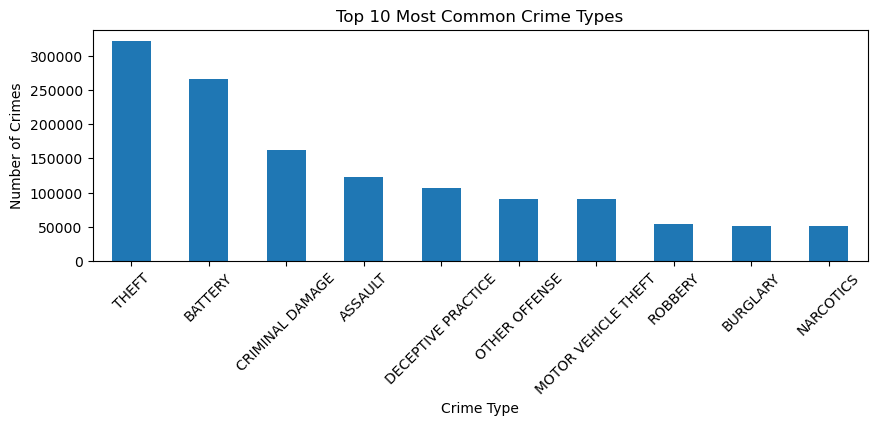

In [24]:
top_crimes = crime["primary_type"].value_counts().head(10)

plt.figure(figsize=(10,3))
top_crimes.plot(kind="bar")

plt.title("Top 10 Most Common Crime Types")
plt.xlabel("Crime Type")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45)

plt.show()

# crime by year

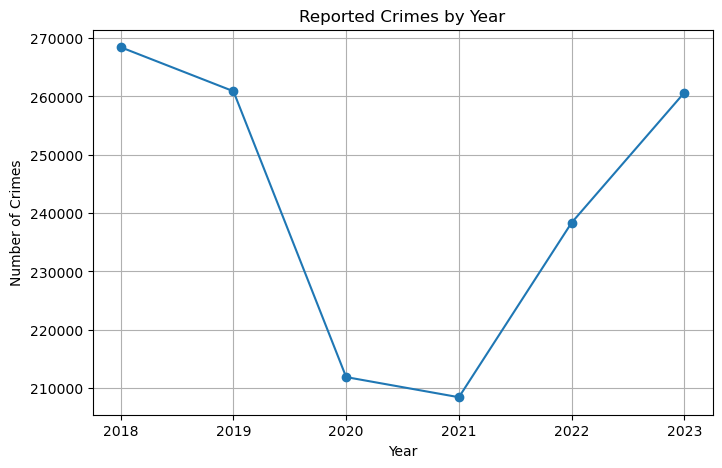

In [43]:
crime_by_year = crime.groupby("year").size()

plt.figure(figsize=(8,5))
crime_by_year.plot(kind="line", marker="o")

plt.title("Reported Crimes by Year")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")

plt.grid(True)

plt.show()

# Crimes by month

C:\Users\vibha\AppData\Local\Temp\ipykernel_2132\3600672298.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crime_by_month = crime.groupby("Month_Name").size()


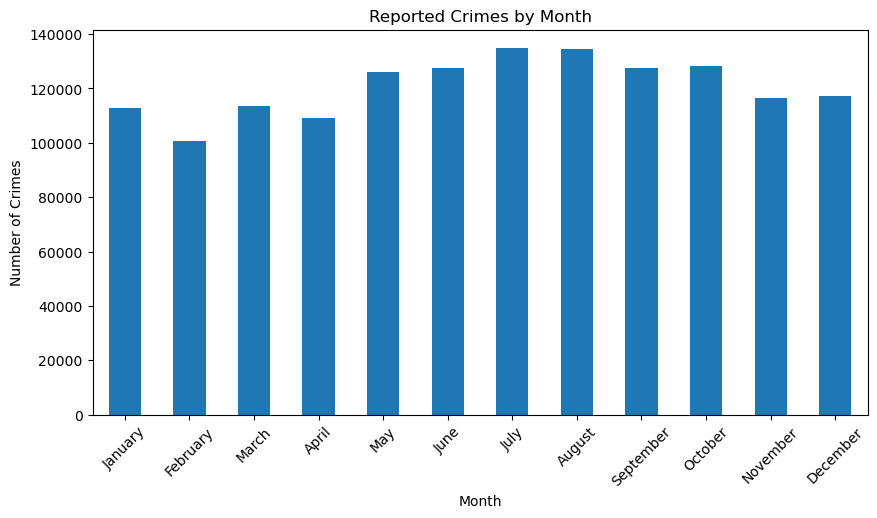

In [44]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

crime["Month_Name"] = pd.Categorical(
    crime["Month_Name"],
    categories=month_order,
    ordered=True
)

crime_by_month = crime.groupby("Month_Name").size()

plt.figure(figsize=(10,5))
crime_by_month.plot(kind="bar")

plt.title("Reported Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")

plt.xticks(rotation=45)

plt.show()
#bar-graph

# CRIMES BY DAY OF WEEK

C:\Users\vibha\AppData\Local\Temp\ipykernel_13104\806840105.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crime.groupby("Day_Name").size().plot(kind="bar", figsize=(8,5),color="black")


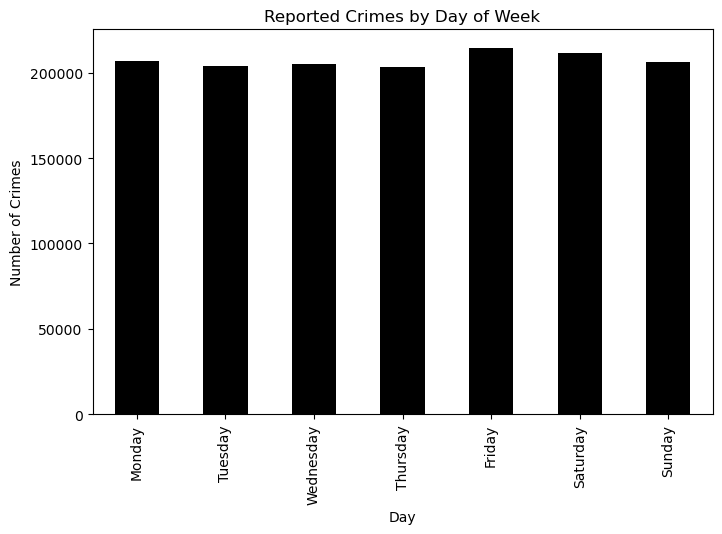

In [20]:
#bar-graph
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

crime["Day_Name"] = pd.Categorical(
    crime["Day_Name"],
    categories=day_order,
    ordered=True
)

crime.groupby("Day_Name").size().plot(kind="bar", figsize=(8,5),color="black")

plt.title("Reported Crimes by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Crimes")

plt.show()

# ARREST DISTRIBUTION

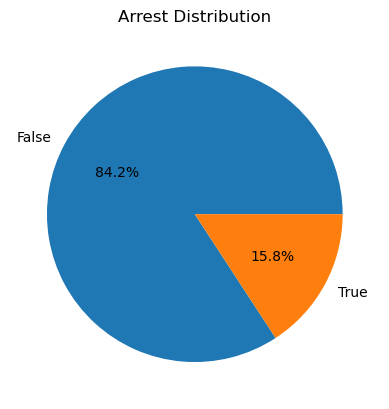

In [17]:
crime["arrest"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Arrest Distribution")

plt.show()
#piechart

84.2% (False): No arrest was made for 84.2% of the reported crimes.
15.8% (True): An arrest was made for only 15.8% of the reported crimes.

So, out of every 100 reported crimes:
About 84 did not result in an arrest.
About 16 did result in an arrest.
Approximately 84.2% of reported crimes did not lead to an arrest, while only 15.8% resulted in an arrest. This indicates that most reported incidents remained unresolved at the time the data was recorded or did not immediately result in an arrest

In [13]:
weather["weather_date"] = pd.to_datetime(weather["weather_date"])

daily_crimes = (
    crime.groupby(crime["date_reported"].dt.date)
         .size()
         .reset_index(name="crime_count")
)

daily_crimes["date_reported"] = pd.to_datetime(daily_crimes["date_reported"])

crime_weather = pd.merge(
    daily_crimes,
    weather,
    left_on="date_reported",
    right_on="weather_date",
    how="inner"
)

crime_weather.head()

,date_reported,crime_count,weather_date,temp_high,temp_low,average,precipitation
0,2018-01-01,994,2018-01-01,1,-9,-4.0,0.0
1,2018-01-02,562,2018-01-02,8,-9,-0.5,0.0
2,2018-01-03,576,2018-01-03,17,6,11.5,0.0
3,2018-01-04,602,2018-01-04,12,0,6.0,0.0
4,2018-01-05,666,2018-01-05,11,-1,5.0,0.0


# CRIME COUNT VS TEMPRATURE

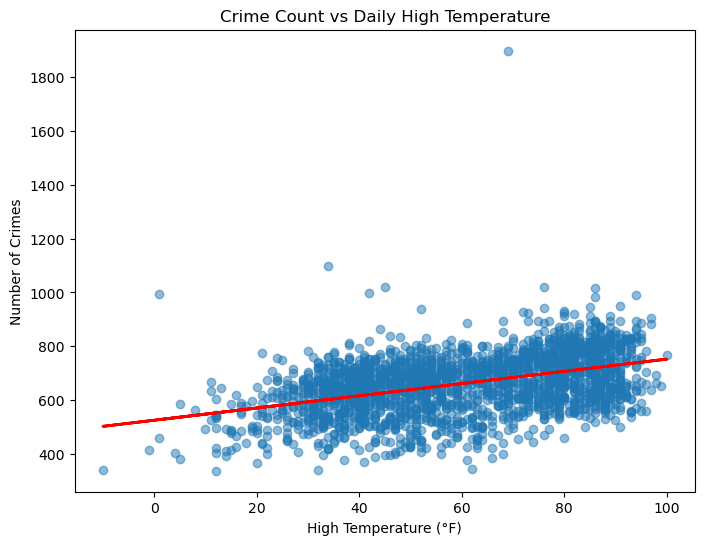

In [16]:
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(
    crime_weather["temp_high"],
    crime_weather["crime_count"],
    alpha=0.5
)

# Trend line
z = np.polyfit(crime_weather["temp_high"], crime_weather["crime_count"], 1)
p = np.poly1d(z)

plt.plot(
    crime_weather["temp_high"],
    p(crime_weather["temp_high"]),
    color="red",
    linewidth=2
)

plt.title("Crime Count vs Daily High Temperature")
plt.xlabel("High Temperature (°F)")
plt.ylabel("Number of Crimes")

plt.show()
#As the daily high temperature increases, the average number of reported crimes also tends to increase.
#Notice that the slope is gentle, not steep. That means the relationship exists but is not very strong.

X-axis: Daily High Temperature (°F)
Y-axis: Number of Crimes Reported on that Day
Each dot: Represents one day from your dataset.
For example:
A dot at (30, 600) means: on a day when the high temperature was 30°F, about 600 crimes were reported.
A dot at (85, 800) means: on a day when the high temperature was 85°F, about 800 crimes were reported.

The scatter plot indicates a weak positive association between daily high temperature and reported crime count. Crime levels generally appear higher on warmer days, although the wide spread of points suggests that temperature is only one of several factors influencing crime. A few outliers with exceptionally high crime counts are also visible.
#As the daily high temperature increases, the average number of reported crimes also tends to increase.
#Notice that the slope is gentle, not steep. That means the relationship exists but is not very strong.

# COORELATION HEATMAP


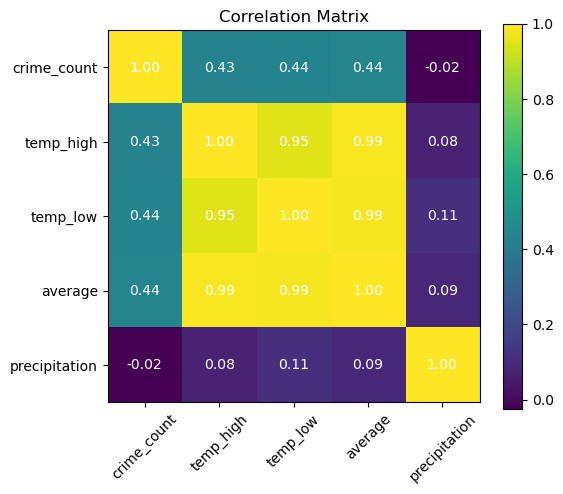

In [22]:
corr = crime_weather[
    ["crime_count", "temp_high", "temp_low", "average", "precipitation"]
].corr()

plt.figure(figsize=(6,5))

plt.imshow(corr, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white"
        )

plt.title("Correlation Matrix")
plt.show()

The correlation analysis indicates that high, low, and average temperatures are strongly correlated, as expected for related weather measurements. Daily crime count exhibits a weak positive correlation with temperature, suggesting a slight increase in crime during warmer days. Precipitation shows little to no correlation with crime count, indicating that rainfall alone is not a strong predictor of daily crime in this dataset. Overall, the results suggest that weather may influence crime patterns to some extent, but additional factors are likely responsible for most of the variation in crime levels.

 # Crime vs Precipitation

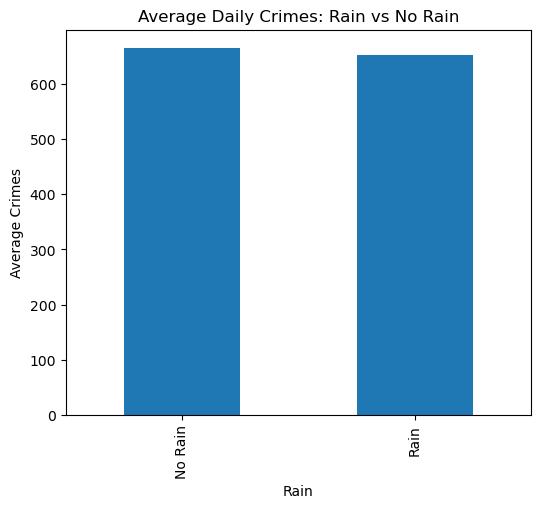

In [51]:
crime_weather["Rain"] = crime_weather["precipitation"].apply(
    lambda x: "Rain" if x > 0 else "No Rain"
)

crime_weather.groupby("Rain")["crime_count"].mean().plot(
    kind="bar",
    figsize=(6,5)
)

plt.title("Average Daily Crimes: Rain vs No Rain")
plt.ylabel("Average Crimes")

plt.show()

# COMMUNITY POPULATION VS CRIME

In [52]:
community_crime = (
    crime.groupby("community_area")
         .size()
         .reset_index(name="crime_count")
)

community_crime = community_crime.merge(
    community,
    left_on="community_area",
    right_on="community_id"
)

community_crime.head()

,community_area,crime_count,community_id,name,population,area_sq_mi,density
0,1,23196,1,rogers park,55628,1.84,30232.61
1,2,21072,2,west ridge,77122,3.53,21847.59
2,3,21620,3,uptown,57182,2.32,24647.41
3,4,11541,4,lincoln square,40494,2.56,15817.97
4,5,7628,5,north center,35114,2.05,17128.78


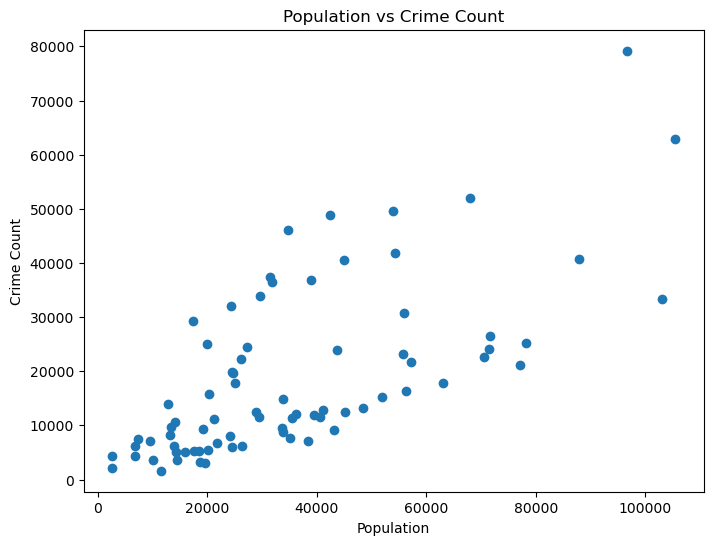

In [54]:
plt.figure(figsize=(8,6))

plt.scatter(
    community_crime["population"],
    community_crime["crime_count"]
)

plt.xlabel("Population")
plt.ylabel("Crime Count")

plt.title("Population vs Crime Count")

plt.show()

The scatter plot shows a moderate positive relationship between community population and reported crime count. While more populated communities generally experience higher crime volumes, the variation among communities of similar population indicates that population alone does not determine crime levels.
Larger communities tend to report more crimes because they have more residents and greater human activity. However, the wide variation among similarly populated communities suggests that additional social, economic, and environmental factors also contribute to crime patterns.

 # DENSITY VS CRIMES

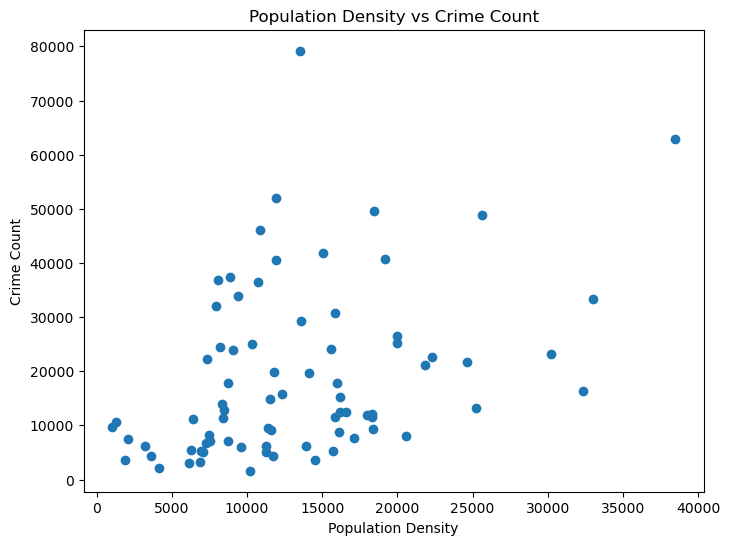

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(
    community_crime["density"],
    community_crime["crime_count"]
)

plt.xlabel("Population Density")
plt.ylabel("Crime Count")

plt.title("Population Density vs Crime Count")

plt.show()

 # Top Communities

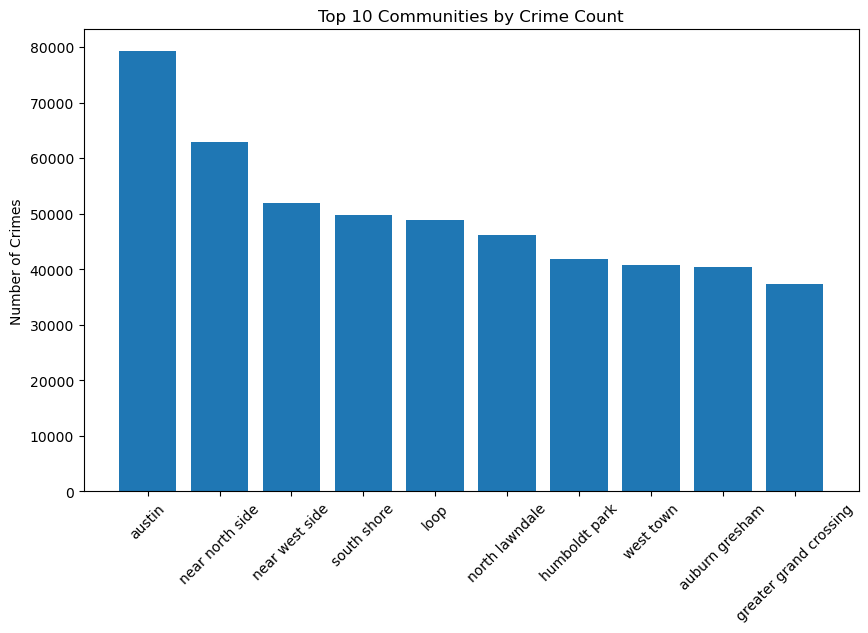

In [56]:
top10 = community_crime.nlargest(10, "crime_count")

plt.figure(figsize=(10,6))

plt.bar(top10["name"], top10["crime_count"])

plt.xticks(rotation=45)

plt.title("Top 10 Communities by Crime Count")
plt.ylabel("Number of Crimes")

plt.show()

# DOMESTIC CRIME VS ARREST

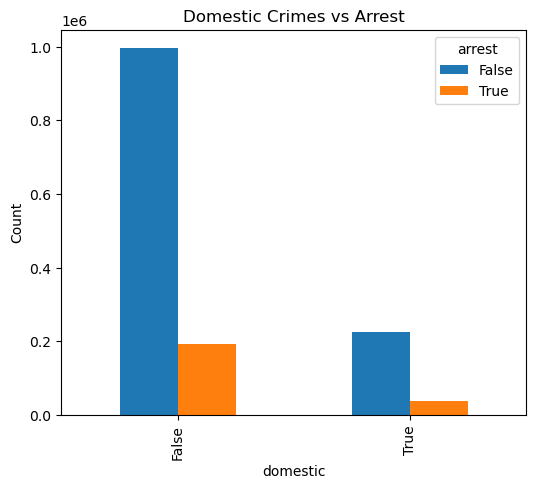

In [57]:
table = pd.crosstab(crime["domestic"], crime["arrest"])

table.plot(kind="bar", figsize=(6,5))

plt.title("Domestic Crimes vs Arrest")
plt.ylabel("Count")

plt.show()